## COMMODITY-SPECIFIC NEWS CLASSIFICATION

# Install & Import Libraries  

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# Global Configuration


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import re
import string
import warnings
warnings.filterwarnings('ignore')

# NLTK
import nltk
nltk.download('stopwords', quiet=True)
nltk.download('punkt',     quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('wordnet',   quiet=True)
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

# Scikit-learn
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)

# WordCloud (opsional)
try:
    from wordcloud import WordCloud
    WORDCLOUD_AVAILABLE = True
except ImportError:
    WORDCLOUD_AVAILABLE = False
    print("[INFO] WordCloud tidak tersedia. Uncomment baris !pip install di atas, lalu restart runtime.")

print("Semua library berhasil diimport.")

Semua library berhasil diimport.


In [ ]:
RANDOM_STATE   = 42
TEST_SIZE      = 0.2
MAX_TFIDF_FEAT = 5000

# Palet warna konsisten per komoditas
PALETTE = {
    'rice'    : '#E07B54',
    'corn'    : '#F5C842',
    'soybean' : '#6BAF92',
    'wheat'   : '#B08850',
    'others'  : '#9E9E9E',
}

# Kamus keyword untuk labeling otomatis
COMMODITY_KEYWORDS = {
    'rice'    : ['rice', 'paddy', 'padi', 'beras'],
    'corn'    : ['corn', 'maize', 'jagung', 'corns'],
    'soybean' : ['soybean', 'soy', 'kedelai', 'soya', 'soybeans'],
    'wheat'   : ['wheat', 'gandum', 'flour'],
}

print("GLobal configuration is ready.")

GLobal configuration is ready.


# Data Load


In [ ]:
FILE_PATH = '/content/drive/MyDrive/NLP_Project/agriculture_news_labeled_full.csv'

df = pd.read_csv(FILE_PATH)

# Pastikan kolom date bertipe datetime
if 'date' in df.columns:
    df['date'] = pd.to_datetime(df['date'], errors='coerce')

print(f"Dataset dimuat: {df.shape[0]:,} baris × {df.shape[1]} kolom")

# --- 5 Data Pertama ---
print("\n── 5 Data Pertama ──")
display(df.head())

# %%
# Missing values & tipe data
print("── Missing Values ──")
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else "Tidak ada missing values")

print("\n── Tipe Data ──")
print(df.dtypes)

Dataset dimuat: 2,595 baris × 4 kolom

── 5 Data Pertama ──


,date,headline,news,commodity
0,2020-12-31,Export Taxes on Argentina Soybeans back to 33%,"As 2020 comes to a close, farmers in Argentina...",soybean
1,2020-12-30,Recent Rains in Central Brazil Help to Stabili...,The weather in Brazil has slowly improved over...,soybean
2,2020-12-30,2.3% of Brazil's Soybeans are Conventional Soy...,A small portion of Brazil's soybean production...,soybean
3,2020-12-29,"Argentina Soy 77% Planted, Rain Needed to Plan...",The soybean estimates in Argentina continue to...,soybean
4,2020-12-29,2020/21 Argentina Corn Only 61% Planted vs. 80...,Rainfall in Argentina continues to be scattere...,corn


── Missing Values ──
Tidak ada missing values

── Tipe Data ──
date         datetime64[ns]
headline             object
news                 object
commodity            object
dtype: object


# EDA


### Distribusi Panjang Teks

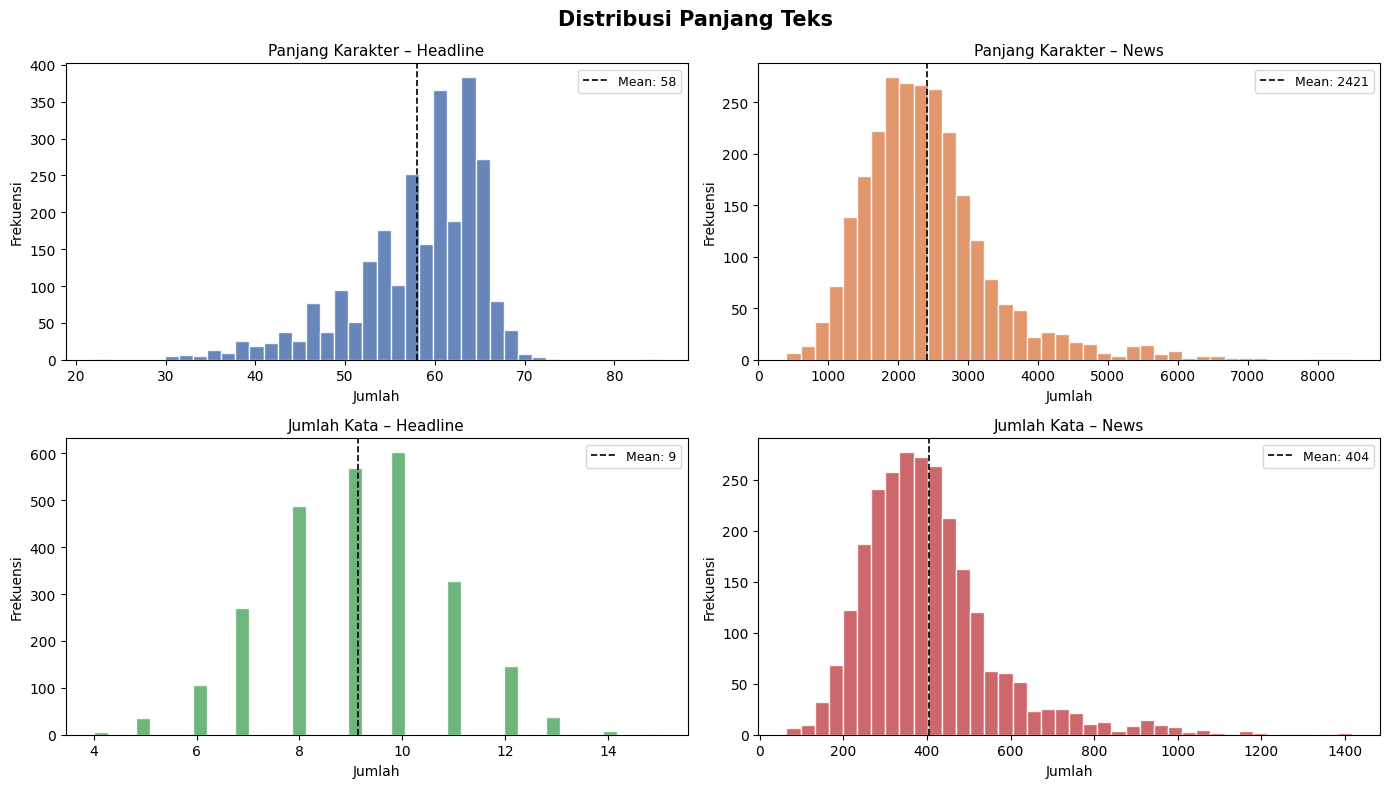


Statistik Deskriptif:


,headline_wc,news_wc
count,2595.0,2595.0
mean,9.1,403.9
std,1.7,163.1
min,4.0,64.0
25%,8.0,297.0
50%,9.0,380.0
75%,10.0,468.0
max,15.0,1416.0


In [ ]:
df['headline_len'] = df['headline'].astype(str).apply(len)
df['news_len']     = df['news'].astype(str).apply(len)
df['headline_wc']  = df['headline'].astype(str).apply(lambda x: len(x.split()))
df['news_wc']      = df['news'].astype(str).apply(lambda x: len(x.split()))

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle('Distribusi Panjang Teks', fontsize=15, fontweight='bold')

for ax, col, title, color in zip(
    axes.flat,
    ['headline_len', 'news_len', 'headline_wc', 'news_wc'],
    ['Panjang Karakter – Headline', 'Panjang Karakter – News',
     'Jumlah Kata – Headline',      'Jumlah Kata – News'],
    ['#4C72B0', '#DD8452', '#55A868', '#C44E52']
):
    ax.hist(df[col], bins=40, color=color, edgecolor='white', alpha=0.85)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('Jumlah')
    ax.set_ylabel('Frekuensi')
    mean_val = df[col].mean()
    ax.axvline(mean_val, color='black', linestyle='--', linewidth=1.2,
               label=f'Mean: {mean_val:.0f}')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

# Statistik deskriptif
print("\nStatistik Deskriptif:")
df[['headline_wc', 'news_wc']].describe().round(1)

### Word Frequency Top 20      

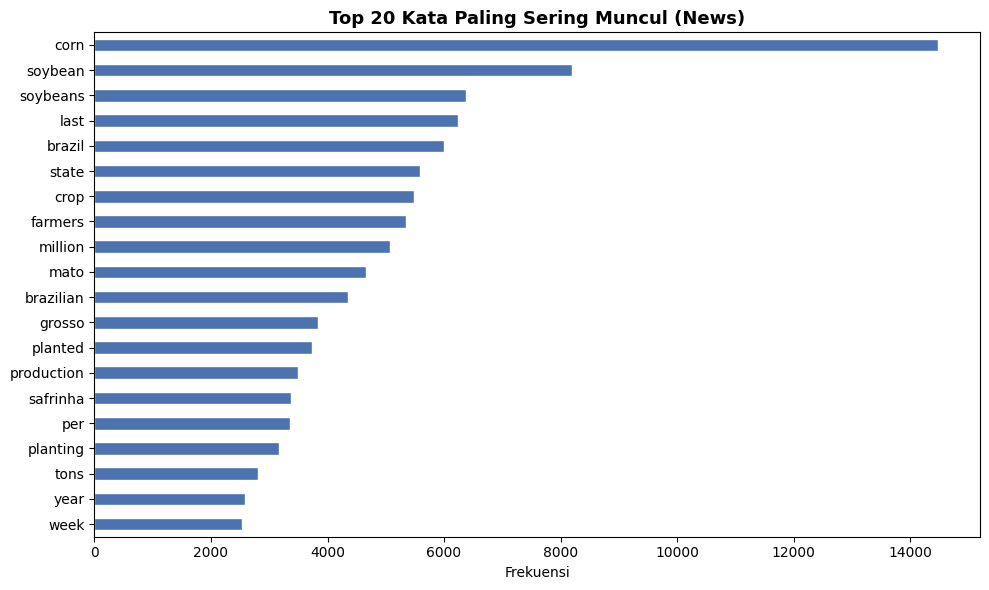

In [ ]:
all_words = ' '.join(df['news'].astype(str)).lower().split()
stop_en   = set(stopwords.words('english'))
filtered  = [w for w in all_words if w.isalpha() and w not in stop_en and len(w) > 2]

freq = pd.Series(filtered).value_counts().head(20)

fig, ax = plt.subplots(figsize=(10, 6))
freq.sort_values().plot(kind='barh', ax=ax, color='#4C72B0', edgecolor='white')
ax.set_title('Top 20 Kata Paling Sering Muncul (News)', fontsize=13, fontweight='bold')
ax.set_xlabel('Frekuensi')
plt.tight_layout()
plt.show()

# Data Preprocessing

In [ ]:
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english')) - {'not', 'no'}

def preprocess_steps(text):
    steps = []

    # 1. Lowercase
    before = text
    text = text.lower()
    steps.append(("Data Cleaning - Lowercase", before, text))

    # 2. Remove punctuation
    before = text
    text = text.translate(str.maketrans('', '', string.punctuation))
    steps.append(("Data Cleaning - Remove Punctuation", before, text))

    # 3. Remove numbers
    before = text
    text = re.sub(r'\d+', '', text)
    steps.append(("Data Cleaning - Remove Numbers", before, text))

    # 4. Tokenization
    before = text
    tokens = word_tokenize(text)
    steps.append(("Data Transformation - Tokenization", before, tokens))

    # 5. Remove stopwords
    before = tokens
    tokens = [t for t in tokens if t not in stop_words and len(t) > 1]
    steps.append(("Data Cleaning - Remove Stopwords", before, tokens))

    # 6. Lemmatization
    before = tokens
    tokens = [lemmatizer.lemmatize(t, pos='v') for t in tokens]
    steps.append(("Data Transformation - Lemmatization", before, tokens))

    # Final
    before = tokens
    final_text = ' '.join(tokens)
    steps.append(("Final Result", before, final_text))

    return steps


def create_preprocessing_table(df, column, index=0):
    text = str(df[column].iloc[index])
    steps = preprocess_steps(text)
    table = pd.DataFrame(steps, columns=["Step", "Before", "After"])
    return table

def preprocess_text(text):
    steps = preprocess_steps(text)
    return steps[-1][2]  # ambil final_text

df['news_clean'] = df['news'].astype(str).apply(preprocess_text)

print(df[['news', 'news_clean']].head())

table_news = create_preprocessing_table(df, 'news', index=0)
table_news

                                                news  \
0  As 2020 comes to a close, farmers in Argentina...   
1  The weather in Brazil has slowly improved over...   
2  A small portion of Brazil's soybean production...   
3  The soybean estimates in Argentina continue to...   
4  Rainfall in Argentina continues to be scattere...   

                                          news_clean  
0  come close farmers argentina lot things worry ...  
1  weather brazil slowly improve past weeks rainf...  
2  small portion brazils soybean production still...  
3  soybean estimate argentina continue move lower...  
4  rainfall argentina continue scatter less ideal...  


,Step,Before,After
0,Data Cleaning - Lowercase,"As 2020 comes to a close, farmers in Argentina...","as 2020 comes to a close, farmers in argentina..."
1,Data Cleaning - Remove Punctuation,"as 2020 comes to a close, farmers in argentina...",as 2020 comes to a close farmers in argentina ...
2,Data Cleaning - Remove Numbers,as 2020 comes to a close farmers in argentina ...,as comes to a close farmers in argentina have...
3,Data Transformation - Tokenization,as comes to a close farmers in argentina have...,"[as, comes, to, a, close, farmers, in, argenti..."
4,Data Cleaning - Remove Stopwords,"[as, comes, to, a, close, farmers, in, argenti...","[comes, close, farmers, argentina, lot, things..."
5,Data Transformation - Lemmatization,"[comes, close, farmers, argentina, lot, things...","[come, close, farmers, argentina, lot, things,..."
6,Final Result,"[come, close, farmers, argentina, lot, things,...",come close farmers argentina lot things worry ...


# Feature Extraction

## BoW

In [ ]:

from sklearn.feature_extraction.text import CountVectorizer

TOP_N    = 10
SAMPLE_N = 5

# ===== FIT TRANSFORM =====
bow_vectorizer = CountVectorizer(
    max_features = MAX_TFIDF_FEAT,
    ngram_range  = (1, 1),
    min_df       = 2
)

X_bow = bow_vectorizer.fit_transform(df['news_clean'])

# ===== BEFORE =====
before_sample = df[['news_clean', 'commodity']].head(SAMPLE_N).reset_index(drop=True)

# ===== AFTER – ambil top fitur dari sparse matrix =====
feature_names  = bow_vectorizer.get_feature_names_out()
top_indices    = X_bow.sum(axis=0).A1.argsort()[::-1][:TOP_N]
top_features   = feature_names[top_indices]

X_sample       = X_bow[:SAMPLE_N, :][:, top_indices].toarray()
after_bow      = pd.DataFrame(X_sample, columns=top_features).astype(int)

# ===== TAMPILKAN =====
comparison_bow = pd.concat([before_sample, after_bow], axis=1)

print("=== BEFORE vs AFTER – Bag of Words (Top 10 Fitur) ===")
display(comparison_bow)

print(f"\nJumlah fitur : {X_bow.shape[1]:,}")
print(f"Ukuran matrix: {X_bow.shape[0]:,} × {X_bow.shape[1]:,}")

=== BEFORE vs AFTER – Bag of Words (Top 10 Fitur) ===


,news_clean,commodity,corn,plant,state,soybean,brazil,soybeans,crop,last,farmers,million
0,come close farmers argentina lot things worry ...,soybean,1,0,0,3,0,1,0,0,2,0
1,weather brazil slowly improve past weeks rainf...,soybean,0,8,6,10,5,15,4,7,5,8
2,small portion brazils soybean production still...,soybean,0,1,4,16,4,8,0,0,0,5
3,soybean estimate argentina continue move lower...,soybean,0,14,0,6,0,11,4,7,2,0
4,rainfall argentina continue scatter less ideal...,corn,15,15,0,0,0,0,2,8,2,0



Jumlah fitur : 5,000
Ukuran matrix: 2,595 × 5,000


## N-Grams (Bigram)

In [ ]:
# ┌─────────────────────────────────────────────────────────┐
# │  FEATURE EXTRACTION – N-Grams (Bigram)                  │
# └─────────────────────────────────────────────────────────┘

# ===== FIT TRANSFORM =====
ngram_vectorizer = CountVectorizer(
    max_features = MAX_TFIDF_FEAT,
    ngram_range  = (2, 2),    # bigram murni
    min_df       = 2
)

X_ngram = ngram_vectorizer.fit_transform(df['news_clean'])

# ===== BEFORE =====
before_sample = df[['news_clean', 'commodity']].head(SAMPLE_N).reset_index(drop=True)

# ===== AFTER – ambil top fitur dari sparse matrix =====
feature_names_ng = ngram_vectorizer.get_feature_names_out()
top_indices_ng   = X_ngram.sum(axis=0).A1.argsort()[::-1][:TOP_N]
top_features_ng  = feature_names_ng[top_indices_ng]

X_sample_ng      = X_ngram[:SAMPLE_N, :][:, top_indices_ng].toarray()
after_ngram      = pd.DataFrame(X_sample_ng, columns=top_features_ng).astype(int)

# ===== TAMPILKAN =====
comparison_ngram = pd.concat([before_sample, after_ngram], axis=1)

print("=== BEFORE vs AFTER – N-Grams Bigram (Top 10 Fitur) ===")
display(comparison_ngram)

print(f"\nJumlah fitur : {X_ngram.shape[1]:,}")
print(f"Ukuran matrix: {X_ngram.shape[0]:,} × {X_ngram.shape[1]:,}")

=== BEFORE vs AFTER – N-Grams Bigram (Top 10 Fitur) ===


,news_clean,commodity,mato grosso,million tons,safrinha corn,last week,last year,corn crop,grow season,soybean crop,compare last,southern brazil
0,come close farmers argentina lot things worry ...,soybean,0,0,0,0,0,0,1,0,0,0
1,weather brazil slowly improve past weeks rainf...,soybean,7,2,0,2,4,0,0,2,4,1
2,small portion brazils soybean production still...,soybean,3,1,0,0,0,0,0,0,0,0
3,soybean estimate argentina continue move lower...,soybean,0,0,0,3,3,0,0,2,4,0
4,rainfall argentina continue scatter less ideal...,corn,0,0,0,4,4,2,0,0,4,0



Jumlah fitur : 5,000
Ukuran matrix: 2,595 × 5,000


## TF-IDF

In [ ]:
import pandas as pd

# ===== 1. BEFORE (teks asli hasil preprocessing) =====
before_df = df[['news_clean', 'commodity']].copy().reset_index(drop=True)

# ===== 2. TF-IDF =====
vectorizer = TfidfVectorizer(
    max_features=MAX_TFIDF_FEAT,
    ngram_range=(1, 2),
    min_df=2,
    sublinear_tf=True
)

X = vectorizer.fit_transform(df['news_clean'])
y = df['commodity']

# ===== 3. Ambil TOP fitur berdasarkan total TF-IDF score =====
TOP_N = 10
feature_names = vectorizer.get_feature_names_out()

# Hitung sum per fitur langsung dari sparse matrix (aman di memori)
top_indices = X.sum(axis=0).A1.argsort()[::-1][:TOP_N]
top_features = feature_names[top_indices]

# ===== 4. Ambil beberapa baris sample saja SEBELUM toarray() =====
sample_size = 5
X_sample = X[:sample_size, :][:, top_indices].toarray()  # toarray() hanya pada subset kecil

tfidf_top = pd.DataFrame(X_sample, columns=top_features).round(4)

# ===== 5. Gabungkan BEFORE vs AFTER =====
before_sample = before_df[['news_clean', 'commodity']].head(sample_size).reset_index(drop=True)

comparison = pd.concat([before_sample, tfidf_top], axis=1)

# ===== 6. Tampilkan =====
print("=== BEFORE vs AFTER TF-IDF (Top 10 Features) ===")
display(comparison)

print(f"\nJumlah fitur TF-IDF : {X.shape[1]:,}")
print(f"Ukuran matrix       : {X.shape[0]:,} × {X.shape[1]:,}")
print(f"Jumlah kelas        : {y.nunique()} → {list(y.unique())}")

=== BEFORE vs AFTER TF-IDF (Top 10 Features) ===


,news_clean,commodity,corn,state,plant,brazil,soybean,crop,soybeans,farmers,last,grosso
0,come close farmers argentina lot things worry ...,soybean,0.0268,0.0000,0.0000,0.0000,0.0569,0.0000,0.0276,0.0462,0.0000,0.0000
1,weather brazil slowly improve past weeks rainf...,soybean,0.0000,0.0448,0.0570,0.0404,0.0553,0.0379,0.0633,0.0440,0.0476,0.0608
2,small portion brazils soybean production still...,soybean,0.0000,0.0535,0.0259,0.0517,0.0883,0.0000,0.0735,0.0000,0.0000,0.0605
3,soybean estimate argentina continue move lower...,soybean,0.0000,0.0000,0.0885,0.0000,0.0614,0.0498,0.0762,0.0375,0.0625,0.0000
4,rainfall argentina continue scatter less ideal...,corn,0.0811,0.0000,0.0909,0.0000,0.0000,0.0356,0.0000,0.0378,0.0659,0.0000



Jumlah fitur TF-IDF : 5,000
Ukuran matrix       : 2,595 × 5,000
Jumlah kelas        : 5 → ['soybean', 'corn', 'rice', 'others', 'wheat']
